In [8]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score,roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, Dataset
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier



SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)

sns.set_theme(style="whitegrid", context="notebook")
DEVICE = torch.device("cpu")
print("PyTorch", torch.__version__, "| устройство:", DEVICE)

PyTorch 2.14.0+cpu | устройство: cpu


In [9]:
from pathlib import Path
train = pd.read_csv(r"C:\Users\Booss\Documents\projects\works\csv-ки\train.csv")
validation = pd.read_csv(r"C:\Users\Booss\Documents\projects\works\csv-ки\validation.csv")
test = pd.read_csv(r"C:\Users\Booss\Documents\projects\works\csv-ки\test.csv")

feature_columns = [
    column
    for column in train.columns
    if column not in {"row_id", "target"}
]

validation_features = [
    column
    for column in validation.columns
    if column not in {"row_id", "target"}
]

test_features = [
    column
    for column in test.columns
    if column != "row_id"
]

assert feature_columns == validation_features == test_features

X_train = train[feature_columns]
y_train = train["target"]

X_validation = validation[feature_columns]
y_validation = validation["target"]

X_test = test[feature_columns]

In [10]:
test.head()

,row_id,f0000,f0001,f0002,f0003,f0004,f0005,f0006,f0007,f0008,...,f0502,f0503,f0504,f0505,f0506,f0507,f0508,f0509,f0510,f0511
0,row_46ad1afad8562239f79c,0.244810,0.114570,0.007334,0.023760,0.387686,0.149363,0.945092,0.013998,0.000000,...,0.275527,0.248542,0.292501,0.260105,0.075953,0.119261,0.098756,0.215996,0.578230,0.000233
1,row_b42ade9cd57b8d919acb,1.896484,0.131558,0.095100,0.102150,0.008930,0.092205,0.130427,0.019269,0.700132,...,0.078451,0.094636,0.127212,0.052143,0.707156,0.747834,0.129984,0.242671,0.692840,0.194765
2,row_c951cd5e197b6b4e8b83,1.521355,0.284507,0.409720,0.207996,0.011174,1.192619,0.790904,0.139842,0.120414,...,0.273042,0.075460,0.864784,0.563859,0.148395,0.194541,0.161783,0.412439,1.115551,0.059842
3,row_a54b3423760d599416ce,2.427760,0.875640,1.255399,0.113083,0.182349,1.190072,1.121677,0.397405,0.631804,...,2.586512,1.683931,1.133419,1.548128,0.126427,7.058036,0.229949,0.278353,3.893234,0.067383
4,row_a87c87cc47690e2a303f,1.392432,0.120985,0.118925,0.568936,0.293686,0.628145,0.508286,0.019553,0.445561,...,0.413616,0.258653,0.265331,0.161138,0.068309,1.087377,0.058649,0.169336,0.004852,0.056881


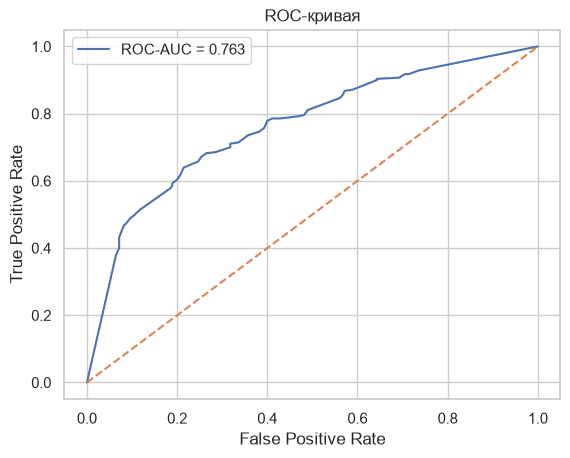

In [12]:
BestTreeModel = DecisionTreeClassifier(criterion='gini',max_depth=10,min_samples_leaf=20,min_samples_split=2,max_features=0.5)
#параметры были найдены через GridSearchCV
BestTreeModel.fit(X_train,y_train)
probabilities = BestTreeModel.predict_proba(X_validation)[:,1]
fpr, tpr, thresholds = roc_curve(y_validation, probabilities)
auc = roc_auc_score(y_validation, probabilities)
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая")
plt.legend()
plt.show()

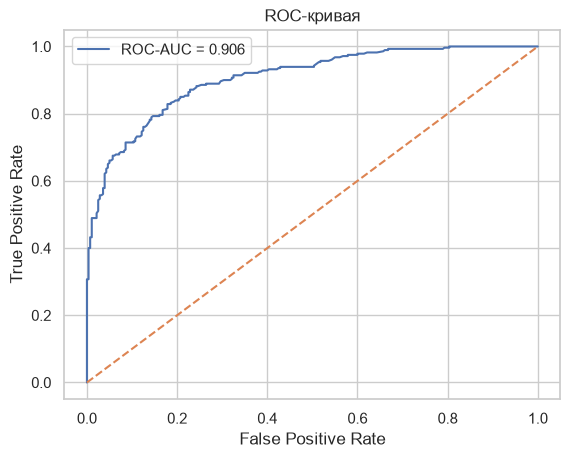

In [14]:
BestRandForest = RandomForestClassifier(n_estimators=1000,criterion='gini',max_depth=None,min_samples_leaf=1,min_samples_split=2,max_features=0.15)
#параметры были найдены через GridSearchCV
BestRandForest.fit(X_train,y_train)
probabilities = BestRandForest.predict_proba(X_validation)[:,1]
fpr, tpr, thresholds = roc_curve(y_validation, probabilities)
auc = roc_auc_score(y_validation, probabilities)
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая")
plt.legend()
plt.show()

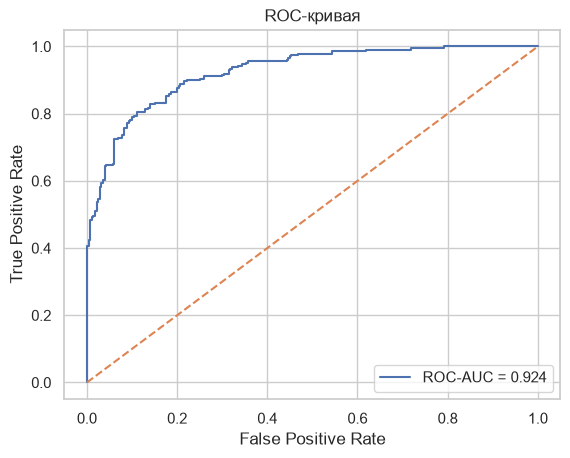

In [16]:
BestGradientBoost = GradientBoostingClassifier(n_estimators=600,max_depth=5,learning_rate=0.15, random_state=42)
#параметры были найдены через GridSearchCV
BestGradientBoost.fit(X_train,y_train)
probabilities = BestGradientBoost.predict_proba(X_validation)[:,1]
fpr, tpr, thresholds = roc_curve(y_validation, probabilities)
auc = roc_auc_score(y_validation, probabilities)
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая")
plt.legend()
plt.show()

In [17]:
p_rf = BestRandForest.predict_proba(X_validation)[:, 1]
p_gb = BestGradientBoost.predict_proba(X_validation)[:, 1]

for w in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    p = w * p_rf + (1 - w) * p_gb
    print(w, roc_auc_score(y_validation, p))

0.2 0.9177933673469387
0.3 0.9179591836734693
0.4 0.9176785714285715
0.5 0.9172959183673469
0.6 0.9166581632653061
0.7 0.9160586734693879
0.8 0.9151785714285714


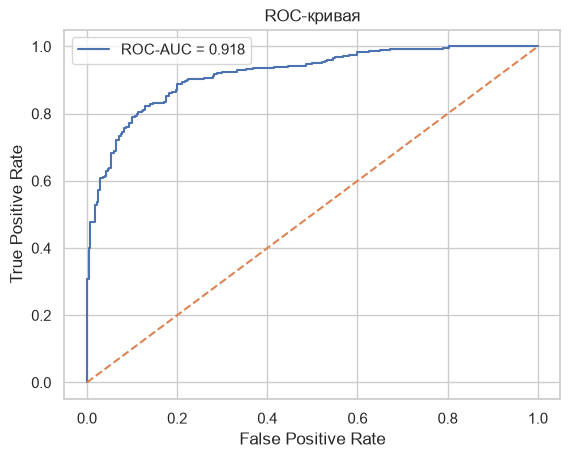

In [18]:
probabilities = BestGradientBoost.predict_proba(X_validation)[:,1]
w = 0.3
fpr, tpr, thresholds = roc_curve(y_validation, w * p_rf + (1 - w) * p_gb)
auc = roc_auc_score(y_validation, w * p_rf + (1 - w) * p_gb)
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая")
plt.legend()
plt.show()

In [23]:
p_tree = BestTreeModel.predict_proba(X_validation)[:, 1]
p_rf = BestRandForest.predict_proba(X_validation)[:, 1]
p_gb = BestGradientBoost.predict_proba(X_validation)[:, 1]

print("Tree:", roc_auc_score(y_validation, p_tree))
print("RF:", roc_auc_score(y_validation, p_rf))
print("GB:", roc_auc_score(y_validation, p_gb))

Tree: 0.7631632653061224
RF: 0.9058737244897959
GB: 0.9242984693877551


In [25]:
from sklearn.ensemble import ExtraTreesClassifier

extra = ExtraTreesClassifier(
    n_estimators=1000,
    max_features=0.2,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

extra.fit(X_train, y_train)

p_extra = extra.predict_proba(X_validation)[:, 1]

print(
    "ExtraTrees:",
    roc_auc_score(y_validation, p_extra)
)

ExtraTrees: 0.9218686224489796


In [26]:
for w_rf in [0, 0.1, 0.2, 0.3]:
    for w_extra in [0, 0.1, 0.2, 0.3]:
        
        w_gb = 1 - w_rf - w_extra
        
        if w_gb < 0:
            continue
        
        p = (
            w_gb * p_gb +
            w_rf * p_rf +
            w_extra * p_extra
        )
        
        score = roc_auc_score(y_validation, p)
        
        print(
            f"GB={w_gb:.1f}, RF={w_rf:.1f}, "
            f"Extra={w_extra:.1f}: {score:.5f}"
        )

GB=1.0, RF=0.0, Extra=0.0: 0.92430
GB=0.9, RF=0.0, Extra=0.1: 0.92589
GB=0.8, RF=0.0, Extra=0.2: 0.92614
GB=0.7, RF=0.0, Extra=0.3: 0.92671
GB=0.9, RF=0.1, Extra=0.0: 0.91852
GB=0.8, RF=0.1, Extra=0.1: 0.92260
GB=0.7, RF=0.1, Extra=0.2: 0.92423
GB=0.6, RF=0.1, Extra=0.3: 0.92526
GB=0.8, RF=0.2, Extra=0.0: 0.91779
GB=0.7, RF=0.2, Extra=0.1: 0.92130
GB=0.6, RF=0.2, Extra=0.2: 0.92291
GB=0.5, RF=0.2, Extra=0.3: 0.92392
GB=0.7, RF=0.3, Extra=0.0: 0.91796
GB=0.6, RF=0.3, Extra=0.1: 0.92005
GB=0.5, RF=0.3, Extra=0.2: 0.92188
GB=0.4, RF=0.3, Extra=0.3: 0.92236


In [27]:
for w in [0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:
    p = w * p_gb + (1 - w) * p_extra
    
    score = roc_auc_score(y_validation, p)
    
    print(
        f"GB={w:.2f}, "
        f"Extra={1-w:.2f}: "
        f"{score:.6f}"
    )

GB=0.55, Extra=0.45: 0.927245
GB=0.60, Extra=0.40: 0.927079
GB=0.65, Extra=0.35: 0.926773
GB=0.70, Extra=0.30: 0.926709
GB=0.75, Extra=0.25: 0.926480
GB=0.80, Extra=0.20: 0.926135


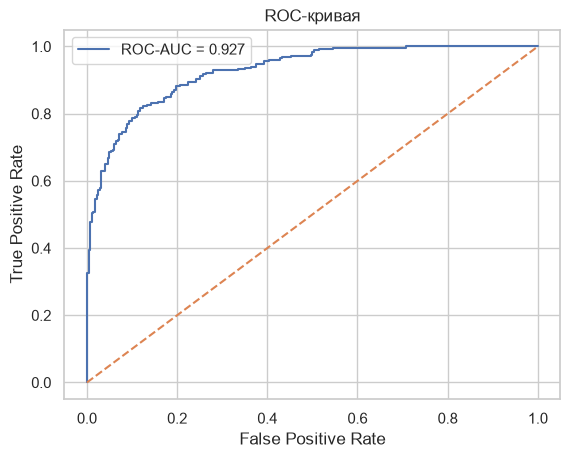

In [28]:
p = 0.55 * p_gb + 0.45 * p_extra
probabilities = BestGradientBoost.predict_proba(X_validation)[:,1]
fpr, tpr, thresholds = roc_curve(y_validation, p)
auc = roc_auc_score(y_validation, p)
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая")
plt.legend()
plt.show()

In [29]:
from sklearn.ensemble import GradientBoostingClassifier, ExtraTreesClassifier

gb_final = GradientBoostingClassifier(
    learning_rate=0.15,
    max_depth=5,
    n_estimators=600,
    random_state=42
)

gb_final.fit(X_train, y_train)

p_gb_test = gb_final.predict_proba(X_test)[:, 1]


extra_final = ExtraTreesClassifier(
    n_estimators=1000,
    max_features=0.2,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

extra_final.fit(X_train, y_train)

p_extra_test = extra_final.predict_proba(X_test)[:, 1]


test_proba = (
    0.55 * p_gb_test +
    0.45 * p_extra_test
)


# 4. Submission
submission = pd.DataFrame({
    'row_id': test['row_id'],
    'target': test_proba
})

submission.to_csv('submission_alpha.csv', index=False)